In [1]:
%pip install pennylane matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 101.4 MB/s eta 0:00:00
  Attempting uninstall: autograd
    Found existing installation: autograd 1.9.1
    Uninstalling autograd-1.9.1:
      Successfully uninstalled autograd-1.9.1


In [8]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Environment ready!")

Environment ready!


EXAMPLE 1: QUANTUM MAGNET (ISING MODEL)

1. THE RULEBOOK (Hamiltonian H):
-1.0 * (Z(0) @ Z(1)) + -1.0 * (Z(1) @ Z(2)) + -0.5 * X(0) + -0.5 * X(1) + -0.5 * X(2)

2. THE TARGET (Exact Theoretical E0): -2.403212

3. THE QUANTUM CIRCUIT (Ansatz):
0: ──RY(0.52)─╭●──RY(0.61)───────────┤ ╭<𝓗>
1: ──RY(0.43)─╰X─╭●─────────RY(0.14)─┤ ├<𝓗>
2: ──RY(0.29)────╰X─────────RY(0.29)─┤ ╰<𝓗>

4. STARTING POINT:
   Initial Parameters (θ): [0.525 0.432 0.291 0.612 0.139 0.292]
   Initial Energy E(θ)   : -2.291072

5. OPTIMIZATION STEPS:
Step       | Calculated E(θ)    | Distance from E0  
----------------------------------------------------
Step 1     | -2.291072          | 0.112140          
Step 5     | -2.326413          | 0.076799          
Step 10    | -2.338113          | 0.065099          
Step 15    | -2.343021          | 0.060191          
Step 20    | -2.346483          | 0.056729          
Step 25    | -2.349414          | 0.053798          
Step 30    | -2.352030          | 0.051182          
St

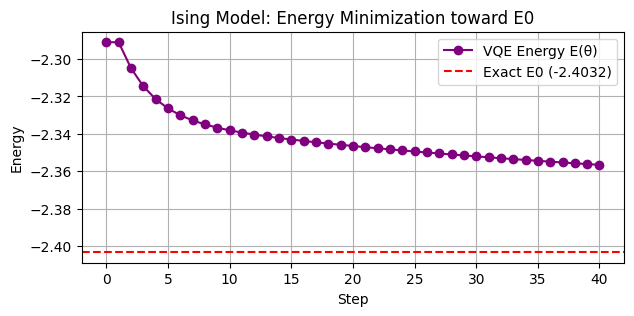

In [13]:
# 1. SETUP & HAMILTONIAN (H)
num_spins = 3
dev_spin = qml.device("default.qubit", wires=num_spins)

# Define H = -1.0*(Z0 Z1) - 1.0*(Z1 Z2) - 0.5*X0 - 0.5*X1 - 0.5*X2
coeffs = [-1.0, -1.0, -0.5, -0.5, -0.5]
obs = [
    qml.PauliZ(0) @ qml.PauliZ(1),
    qml.PauliZ(1) @ qml.PauliZ(2),
    qml.PauliX(0),
    qml.PauliX(1),
    qml.PauliX(2)
]
H_ising = qml.Hamiltonian(coeffs, obs)

# Compute exact theoretical ground state (E0) for comparison
E0_exact_ising = np.min(np.linalg.eigvalsh(qml.matrix(H_ising).real))

print("="*60)
print("EXAMPLE 1: QUANTUM MAGNET (ISING MODEL)")
print("="*60)
print("\n1. THE RULEBOOK (Hamiltonian H):")
print(H_ising)
print(f"\n2. THE TARGET (Exact Theoretical E0): {E0_exact_ising:.6f}")

# 2. QUANTUM CIRCUIT (Ansatz)
@qml.qnode(dev_spin)
def ising_circuit(params):
    for i in range(num_spins):
        qml.RY(params[i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    for i in range(num_spins):
        qml.RY(params[i + num_spins], wires=i)
    return qml.expval(H_ising)

# Initial random parameters (θ)
initial_params = np.random.random(6, requires_grad=True)
initial_energy = ising_circuit(initial_params)

print("\n3. THE QUANTUM CIRCUIT (Ansatz):")
print(qml.draw(ising_circuit)(initial_params))

print(f"\n4. STARTING POINT:")
print(f"   Initial Parameters (θ): {np.round(initial_params, 3)}")
print(f"   Initial Energy E(θ)   : {initial_energy:.6f}")

# 3. OPTIMIZATION LOOP
opt_ising = qml.GradientDescentOptimizer(stepsize=0.1)
params_ising = initial_params.copy()
energy_history_ising = [initial_energy]

print("\n5. OPTIMIZATION STEPS:")
print(f"{'Step':<10} | {'Calculated E(θ)':<18} | {'Distance from E0':<18}")
print("-" * 52)

for step in range(1, 41):
    params_ising, energy = opt_ising.step_and_cost(ising_circuit, params_ising)
    energy_history_ising.append(energy)
    if step % 5 == 0 or step == 1:
        diff = abs(energy - E0_exact_ising)
        print(f"Step {step:<5} | {energy:<18.6f} | {diff:<18.6f}")

# 4. FINAL COMPARISON
final_energy_ising = energy_history_ising[-1]
print("\n6. FINAL RESULT vs TARGET:")
print(f"   VQE Energy Found : {final_energy_ising:.6f}")
print(f"   Exact Target E0  : {E0_exact_ising:.6f}")
print(f"   Final Error      : {abs(final_energy_ising - E0_exact_ising):.6f}")

# Plotting
plt.figure(figsize=(7, 3))
plt.plot(energy_history_ising, color='purple', marker='o', label="VQE Energy E(θ)")
plt.axhline(y=E0_exact_ising, color='red', linestyle='--', label=f"Exact E0 ({E0_exact_ising:.4f})")
plt.title("Ising Model: Energy Minimization toward E0")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.legend()
plt.grid(True)
plt.show()

EXAMPLE 2: HYDROGEN MOLECULE (H2)

1. THE RULEBOOK (Hamiltonian H):
Number of Pauli strings in H: 15
First 3 terms of H:
[-0.042072551947439224 * I([0, 1, 2, 3]), 0.1777135822909176 * Z(0), 0.1777135822909176 * Z(1)]

2. THE TARGET (Exact Theoretical E0): -1.136189 Hartrees

3. THE QUANTUM CIRCUIT (Ansatz):
0: ─╭|Ψ⟩─╭G²(0.00)─┤ ╭<𝓗>
1: ─├|Ψ⟩─├G²(0.00)─┤ ├<𝓗>
2: ─├|Ψ⟩─├G²(0.00)─┤ ├<𝓗>
3: ─╰|Ψ⟩─╰G²(0.00)─┤ ╰<𝓗>

4. STARTING POINT:
   Initial Parameter (θ): 0.000
   Initial Energy E(θ)  : -1.117349 Hartrees

5. OPTIMIZATION STEPS:
Step       | Calculated E(θ)    | Distance from E0  
----------------------------------------------------
Step 1     | -1.117349          | 0.018840          
Step 5     | -1.131206          | 0.004984          
Step 10    | -1.136155          | 0.000035          
Step 15    | -1.134097          | 0.002092          
Step 20    | -1.135705          | 0.000484          
Step 25    | -1.135958          | 0.000231          

6. FINAL RESULT vs TARGET:
   VQE Energy 

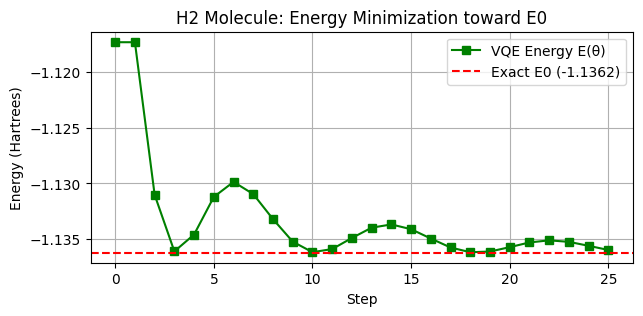

In [15]:
# 1. SETUP & HAMILTONIAN (H)
symbols = ["H", "H"]
coordinates = np.array([0.0, 0.0, -0.6614, 0.0, 0.0, 0.6614])

H_h2, qubits = qml.qchem.molecular_hamiltonian(symbols, coordinates)
dev_chem = qml.device("default.qubit", wires=qubits)

# FIX: Calculate exact theoretical ground state (E0) using np.linalg.eigvalsh
E0_exact_h2 = np.min(np.linalg.eigvalsh(qml.matrix(H_h2).real))

print("="*60)
print("EXAMPLE 2: HYDROGEN MOLECULE (H2)")
print("="*60)
print("\n1. THE RULEBOOK (Hamiltonian H):")
terms = list(H_h2) if hasattr(H_h2, "__iter__") else H_h2.ops
print(f"Number of Pauli strings in H: {len(terms)}")
print(f"First 3 terms of H:\n{terms[:3]}")
print(f"\n2. THE TARGET (Exact Theoretical E0): {E0_exact_h2:.6f} Hartrees")

# 2. QUANTUM CIRCUIT (Ansatz)
@qml.qnode(dev_chem)
def h2_circuit(params):
    qml.BasisState(np.array([1, 1, 0, 0]), wires=range(qubits))
    qml.DoubleExcitation(params[0], wires=[0, 1, 2, 3])
    return qml.expval(H_h2)

initial_params_h2 = np.array([0.0], requires_grad=True)
initial_energy_h2 = h2_circuit(initial_params_h2)

print("\n3. THE QUANTUM CIRCUIT (Ansatz):")
print(qml.draw(h2_circuit)(initial_params_h2))

print(f"\n4. STARTING POINT:")
print(f"   Initial Parameter (θ): {initial_params_h2[0]:.3f}")
print(f"   Initial Energy E(θ)  : {initial_energy_h2:.6f} Hartrees")

# 3. OPTIMIZATION LOOP
opt_h2 = qml.AdamOptimizer(stepsize=0.1)
params_h2 = initial_params_h2.copy()
energy_history_h2 = [initial_energy_h2]

print("\n5. OPTIMIZATION STEPS:")
print(f"{'Step':<10} | {'Calculated E(θ)':<18} | {'Distance from E0':<18}")
print("-" * 52)

for step in range(1, 26):
    params_h2, energy = opt_h2.step_and_cost(h2_circuit, params_h2)
    energy_history_h2.append(energy)
    if step % 5 == 0 or step == 1:
        diff = abs(energy - E0_exact_h2)
        print(f"Step {step:<5} | {energy:<18.6f} | {diff:<18.6f}")

# 4. FINAL COMPARISON
final_energy_h2 = energy_history_h2[-1]
print("\n6. FINAL RESULT vs TARGET:")
print(f"   VQE Energy Found : {final_energy_h2:.6f} Hartrees")
print(f"   Exact Target E0  : {E0_exact_h2:.6f} Hartrees")
print(f"   Final Error      : {abs(final_energy_h2 - E0_exact_h2):.6f} Hartrees")

# Plotting
plt.figure(figsize=(7, 3))
plt.plot(energy_history_h2, color='green', marker='s', label="VQE Energy E(θ)")
plt.axhline(y=E0_exact_h2, color='red', linestyle='--', label=f"Exact E0 ({E0_exact_h2:.4f})")
plt.title("H2 Molecule: Energy Minimization toward E0")
plt.xlabel("Step")
plt.ylabel("Energy (Hartrees)")
plt.legend()
plt.grid(True)
plt.show()